# PR3: Activity Recognition Clustering
# Cluster 34,500 sensor samples (178 features) into 39 clusters
# Evaluated by Normalized Mutual Information (NMI)

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans, BisectingKMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

K = 39
RANDOM_STATE = 42

In [13]:
## Load data
X = pd.read_csv('train.dat', header=None).values
print(f"Shape: {X.shape}")
print(f"Feature range — min: {X.min():.3f}, max: {X.max():.3f}, mean: {X.mean():.3f}, std: {X.std():.3f}")
print(f"Any NaNs: {np.isnan(X).any()}")

Shape: (34500, 178)
Feature range — min: -13.108, max: 12.094, mean: 0.000, std: 1.000
Any NaNs: False


Components for 95% variance: 127
Components for 99% variance: 134


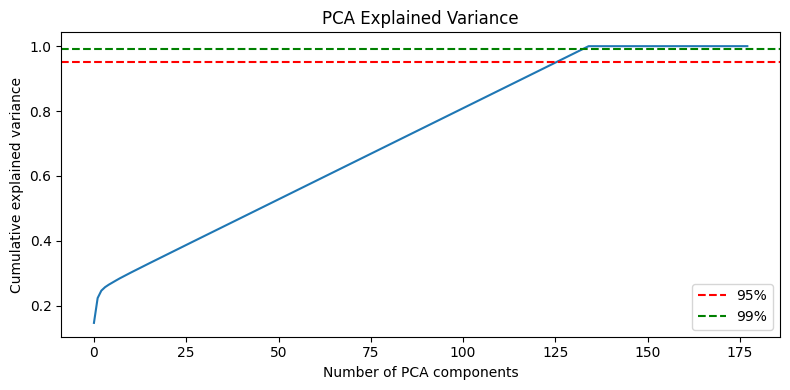

In [14]:
## Preprocessing: StandardScaler then PCA
# Features are already roughly standardized but StandardScaler ensures zero-mean unit-variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA: determine how many components explain 95% and 99% variance
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

n_95 = np.argmax(cumvar >= 0.95) + 1
n_99 = np.argmax(cumvar >= 0.99) + 1
print(f"Components for 95% variance: {n_95}")
print(f"Components for 99% variance: {n_99}")

plt.figure(figsize=(8, 4))
plt.plot(cumvar)
plt.axhline(0.95, color='r', linestyle='--', label='95%')
plt.axhline(0.99, color='g', linestyle='--', label='99%')
plt.xlabel('Number of PCA components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
## Helper: evaluate a clustering with internal metrics
def evaluate(X_feat, labels, name):
    sil = silhouette_score(X_feat, labels, sample_size=5000, random_state=RANDOM_STATE)
    ch  = calinski_harabasz_score(X_feat, labels)
    db  = davies_bouldin_score(X_feat, labels)
    print(f"{name:45s}  Silhouette={sil:.4f}  CH={ch:.1f}  DB={db:.4f}")
    return {'name': name, 'silhouette': sil, 'ch': ch, 'db': db}

results = []  # collect (name, labels, metrics) for comparison

In [16]:
## Install and import UMAP
# UMAP preserves local manifold structure — critical for sensor/activity data
try:
    import umap as umap_lib
    print("umap-learn already available")
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'umap-learn'], check=True)
    import umap as umap_lib
    print("umap-learn installed")

umap-learn already available


In [17]:
## UMAP embeddings — multiple configs
# min_dist=0.0 packs clusters tightly (ideal before K-Means)
# n_neighbors controls local vs global structure
# Precompute embeddings once; reuse across clustering methods

umap_configs = [
    dict(n_components=10, n_neighbors=30,  min_dist=0.0, metric='euclidean'),
    dict(n_components=15, n_neighbors=50,  min_dist=0.0, metric='euclidean'),
    dict(n_components=20, n_neighbors=100, min_dist=0.0, metric='euclidean'),
    dict(n_components=30, n_neighbors=200, min_dist=0.0, metric='euclidean'),
    dict(n_components=15, n_neighbors=50,  min_dist=0.0, metric='cosine'),
]

umap_embeddings = {}
for cfg in umap_configs:
    tag = f"nc{cfg['n_components']}_nn{cfg['n_neighbors']}_m{cfg['metric'][:3]}"
    print(f"Computing UMAP {tag} ...", end=' ', flush=True)
    reducer = umap_lib.UMAP(**cfg, random_state=RANDOM_STATE, low_memory=False)
    umap_embeddings[tag] = reducer.fit_transform(X_scaled)
    print("done")

print("All UMAP embeddings ready.")

Computing UMAP nc10_nn30_meuc ... done
Computing UMAP nc15_nn50_meuc ... done
Computing UMAP nc20_nn100_meuc ... done
Computing UMAP nc30_nn200_meuc ... done
Computing UMAP nc15_nn50_mcos ... done
All UMAP embeddings ready.


In [18]:
## K-Means on every UMAP embedding (n_init=100 for reliable convergence)
results = []  # reset — UMAP methods replace the old PCA-only results

for tag, X_u in umap_embeddings.items():
    km = KMeans(n_clusters=K, init='k-means++', n_init=100, max_iter=500, random_state=RANDOM_STATE)
    lbl = km.fit_predict(X_u)
    m = evaluate(X_u, lbl, f'KMeans+UMAP {tag}')
    results.append({'name': m['name'], 'labels': lbl, **{k: v for k, v in m.items() if k != 'name'}})

KMeans+UMAP nc10_nn30_meuc                     Silhouette=0.3642  CH=15034.9  DB=0.9582
KMeans+UMAP nc15_nn50_meuc                     Silhouette=0.3450  CH=12016.7  DB=0.9961
KMeans+UMAP nc20_nn100_meuc                    Silhouette=0.2928  CH=10002.6  DB=1.0498
KMeans+UMAP nc30_nn200_meuc                    Silhouette=0.2648  CH=8952.3  DB=1.1233
KMeans+UMAP nc15_nn50_mcos                     Silhouette=0.4209  CH=37207.5  DB=0.8856


In [19]:
## GMM on UMAP embeddings (captures non-spherical, overlapping clusters)
# reg_covar regularizes covariance — needed because min_dist=0.0 creates very tight clusters
for tag, X_u in umap_embeddings.items():
    for cov in ['full', 'diag']:
        gmm = GaussianMixture(
            n_components=K, covariance_type=cov,
            n_init=5, max_iter=300, reg_covar=1e-3, random_state=RANDOM_STATE
        )
        lbl = gmm.fit_predict(X_u)
        m = evaluate(X_u, lbl, f'GMM({cov})+UMAP {tag}')
        results.append({'name': m['name'], 'labels': lbl, **{k: v for k, v in m.items() if k != 'name'}})

GMM(full)+UMAP nc10_nn30_meuc                  Silhouette=0.3149  CH=12982.7  DB=1.0227
GMM(diag)+UMAP nc10_nn30_meuc                  Silhouette=0.3467  CH=14372.0  DB=0.9768
GMM(full)+UMAP nc15_nn50_meuc                  Silhouette=0.2707  CH=9822.9  DB=1.1401
GMM(diag)+UMAP nc15_nn50_meuc                  Silhouette=0.3021  CH=10714.6  DB=1.0755
GMM(full)+UMAP nc20_nn100_meuc                 Silhouette=0.2434  CH=7402.1  DB=1.3827
GMM(diag)+UMAP nc20_nn100_meuc                 Silhouette=0.2746  CH=9235.0  DB=1.0942
GMM(full)+UMAP nc30_nn200_meuc                 Silhouette=0.1769  CH=5640.6  DB=1.5988
GMM(diag)+UMAP nc30_nn200_meuc                 Silhouette=0.2379  CH=7945.2  DB=1.3116
GMM(full)+UMAP nc15_nn50_mcos                  Silhouette=0.3515  CH=28427.3  DB=1.1454
GMM(diag)+UMAP nc15_nn50_mcos                  Silhouette=0.3155  CH=21546.7  DB=1.1812


In [20]:
## Extended cosine UMAP search — cosine metric is the clear winner, explore more configs
cosine_configs = [
    dict(n_components=5,  n_neighbors=50,  min_dist=0.0, metric='cosine'),
    dict(n_components=10, n_neighbors=50,  min_dist=0.0, metric='cosine'),
    dict(n_components=15, n_neighbors=30,  min_dist=0.0, metric='cosine'),
    dict(n_components=15, n_neighbors=100, min_dist=0.0, metric='cosine'),
    dict(n_components=20, n_neighbors=50,  min_dist=0.0, metric='cosine'),
    dict(n_components=15, n_neighbors=50,  min_dist=0.0, metric='correlation'),
    dict(n_components=10, n_neighbors=50,  min_dist=0.0, metric='correlation'),
]
for cfg in cosine_configs:
    m_short = cfg['metric'][:3]
    tag = f"nc{cfg['n_components']}_nn{cfg['n_neighbors']}_m{m_short}"
    if tag in umap_embeddings:
        X_u = umap_embeddings[tag]
    else:
        print(f"Computing UMAP {tag} ...", end=' ', flush=True)
        reducer = umap_lib.UMAP(**cfg, random_state=RANDOM_STATE, low_memory=False)
        X_u = reducer.fit_transform(X_scaled)
        umap_embeddings[tag] = X_u
        print("done")
    km = KMeans(n_clusters=K, init='k-means++', n_init=100, max_iter=500, random_state=RANDOM_STATE)
    lbl = km.fit_predict(X_u)
    m = evaluate(X_u, lbl, f'KMeans+UMAP {tag}')
    results.append({'name': m['name'], 'labels': lbl, **{k: v for k, v in m.items() if k != 'name'}})

Computing UMAP nc5_nn50_mcos ... done
KMeans+UMAP nc5_nn50_mcos                      Silhouette=0.4328  CH=39447.3  DB=0.8470
Computing UMAP nc10_nn50_mcos ... done
KMeans+UMAP nc10_nn50_mcos                     Silhouette=0.4188  CH=37391.2  DB=0.8973
Computing UMAP nc15_nn30_mcos ... done
KMeans+UMAP nc15_nn30_mcos                     Silhouette=0.4278  CH=37731.1  DB=0.8445
Computing UMAP nc15_nn100_mcos ... done
KMeans+UMAP nc15_nn100_mcos                    Silhouette=0.3939  CH=30179.4  DB=0.9184
Computing UMAP nc20_nn50_mcos ... done
KMeans+UMAP nc20_nn50_mcos                     Silhouette=0.4324  CH=37350.6  DB=0.8423
Computing UMAP nc15_nn50_mcor ... done
KMeans+UMAP nc15_nn50_mcor                     Silhouette=0.4365  CH=37674.8  DB=0.8506
Computing UMAP nc10_nn50_mcor ... done
KMeans+UMAP nc10_nn50_mcor                     Silhouette=0.4196  CH=37169.3  DB=0.8919


In [21]:
## Agglomerative Ward on all cosine UMAP embeddings
# Ward linkage minimizes within-cluster variance — often beats K-Means on UMAP embeddings
for tag, X_u in umap_embeddings.items():
    if 'cos' not in tag and 'cor' not in tag:
        continue
    agg = AgglomerativeClustering(n_clusters=K, linkage='ward')
    lbl = agg.fit_predict(X_u)
    m = evaluate(X_u, lbl, f'AggWard+UMAP {tag}')
    results.append({'name': m['name'], 'labels': lbl, **{k: v for k, v in m.items() if k != 'name'}})

AggWard+UMAP nc15_nn50_mcos                    Silhouette=0.3999  CH=33407.6  DB=0.8954
AggWard+UMAP nc5_nn50_mcos                     Silhouette=0.4028  CH=35723.3  DB=0.8749
AggWard+UMAP nc10_nn50_mcos                    Silhouette=0.3947  CH=34365.7  DB=0.8800
AggWard+UMAP nc15_nn30_mcos                    Silhouette=0.4178  CH=34614.6  DB=0.8430
AggWard+UMAP nc15_nn100_mcos                   Silhouette=0.3586  CH=27628.4  DB=0.9922
AggWard+UMAP nc20_nn50_mcos                    Silhouette=0.4149  CH=34220.2  DB=0.8740
AggWard+UMAP nc15_nn50_mcor                    Silhouette=0.4098  CH=33996.2  DB=0.8543
AggWard+UMAP nc10_nn50_mcor                    Silhouette=0.3922  CH=33308.1  DB=0.8983


In [22]:
## Very low-dimensional cosine UMAP — extreme compression sometimes tightens clusters further
for nc in [2, 3, 5]:
    tag = f"nc{nc}_nn50_mcos"
    if tag not in umap_embeddings:
        print(f"Computing UMAP {tag} ...", end=' ', flush=True)
        reducer = umap_lib.UMAP(n_components=nc, n_neighbors=50, min_dist=0.0,
                                metric='cosine', random_state=RANDOM_STATE, low_memory=False)
        umap_embeddings[tag] = reducer.fit_transform(X_scaled)
        print("done")
    X_u = umap_embeddings[tag]
    for algo, lbl in [
        ('KMeans',   KMeans(n_clusters=K, init='k-means++', n_init=100, max_iter=500, random_state=RANDOM_STATE).fit_predict(X_u)),
        ('AggWard',  AgglomerativeClustering(n_clusters=K, linkage='ward').fit_predict(X_u)),
    ]:
        m = evaluate(X_u, lbl, f'{algo}+UMAP {tag}')
        results.append({'name': m['name'], 'labels': lbl, **{k: v for k, v in m.items() if k != 'name'}})

Computing UMAP nc2_nn50_mcos ... done
KMeans+UMAP nc2_nn50_mcos                      Silhouette=0.4735  CH=77661.8  DB=0.7023
AggWard+UMAP nc2_nn50_mcos                     Silhouette=0.4367  CH=71479.8  DB=0.7530
Computing UMAP nc3_nn50_mcos ... done
KMeans+UMAP nc3_nn50_mcos                      Silhouette=0.4363  CH=50984.3  DB=0.8419
AggWard+UMAP nc3_nn50_mcos                     Silhouette=0.4262  CH=46354.4  DB=0.8087
KMeans+UMAP nc5_nn50_mcos                      Silhouette=0.4328  CH=39447.3  DB=0.8470
AggWard+UMAP nc5_nn50_mcos                     Silhouette=0.4028  CH=35723.3  DB=0.8749


In [23]:
## Deep search around nc2 cosine — the clear winner so far
# Vary n_neighbors and min_dist to find the best 2D structure
nc2_configs = [
    dict(n_components=2, n_neighbors=15,  min_dist=0.0, metric='cosine'),
    dict(n_components=2, n_neighbors=30,  min_dist=0.0, metric='cosine'),
    dict(n_components=2, n_neighbors=100, min_dist=0.0, metric='cosine'),
    dict(n_components=2, n_neighbors=200, min_dist=0.0, metric='cosine'),
    dict(n_components=2, n_neighbors=50,  min_dist=0.01, metric='cosine'),
    dict(n_components=2, n_neighbors=50,  min_dist=0.05, metric='cosine'),
    dict(n_components=2, n_neighbors=50,  min_dist=0.0, metric='correlation'),
    dict(n_components=3, n_neighbors=30,  min_dist=0.0, metric='cosine'),
    dict(n_components=3, n_neighbors=100, min_dist=0.0, metric='cosine'),
]
for cfg in nc2_configs:
    m_short = cfg['metric'][:3]
    md = cfg['min_dist']
    tag = f"nc{cfg['n_components']}_nn{cfg['n_neighbors']}_md{md}_m{m_short}"
    if tag in umap_embeddings:
        X_u = umap_embeddings[tag]
    else:
        print(f"Computing UMAP {tag} ...", end=' ', flush=True)
        reducer = umap_lib.UMAP(**cfg, random_state=RANDOM_STATE, low_memory=False)
        X_u = reducer.fit_transform(X_scaled)
        umap_embeddings[tag] = X_u
        print("done")
    for algo, lbl in [
        ('KMeans',  KMeans(n_clusters=K, init='k-means++', n_init=100, max_iter=500, random_state=RANDOM_STATE).fit_predict(X_u)),
        ('AggWard', AgglomerativeClustering(n_clusters=K, linkage='ward').fit_predict(X_u)),
    ]:
        m = evaluate(X_u, lbl, f'{algo}+UMAP {tag}')
        results.append({'name': m['name'], 'labels': lbl, **{k: v for k, v in m.items() if k != 'name'}})

Computing UMAP nc2_nn15_md0.0_mcos ... done
KMeans+UMAP nc2_nn15_md0.0_mcos                Silhouette=0.4770  CH=58650.5  DB=0.6995
AggWard+UMAP nc2_nn15_md0.0_mcos               Silhouette=0.4540  CH=55093.1  DB=0.7303
Computing UMAP nc2_nn30_md0.0_mcos ... done
KMeans+UMAP nc2_nn30_md0.0_mcos                Silhouette=0.4829  CH=71256.0  DB=0.6870
AggWard+UMAP nc2_nn30_md0.0_mcos               Silhouette=0.4731  CH=68033.5  DB=0.6846
Computing UMAP nc2_nn100_md0.0_mcos ... done
KMeans+UMAP nc2_nn100_md0.0_mcos               Silhouette=0.4204  CH=66372.2  DB=0.8293
AggWard+UMAP nc2_nn100_md0.0_mcos              Silhouette=0.4145  CH=60082.8  DB=0.7823
Computing UMAP nc2_nn200_md0.0_mcos ... done
KMeans+UMAP nc2_nn200_md0.0_mcos               Silhouette=0.4031  CH=56240.2  DB=0.8178
AggWard+UMAP nc2_nn200_md0.0_mcos              Silhouette=0.3751  CH=50692.1  DB=0.8233
Computing UMAP nc2_nn50_md0.01_mcos ... done
KMeans+UMAP nc2_nn50_md0.01_mcos               Silhouette=0.4589  CH=7622

In [ ]:
## Install all required libraries — run this cell once before running cells 13+
import subprocess, sys

def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", *pkgs, "-q"], check=True)

# Core scientific stack (usually pre-installed)
_pip("numpy", "pandas", "matplotlib", "scikit-learn")
print("numpy / pandas / matplotlib / scikit-learn: OK")

# UMAP dimensionality reduction
_pip("umap-learn")
print("umap-learn: OK")

# PaCMAP — pairwise-controlled manifold approximation (alternative DR)
_pip("pacmap")
print("pacmap: OK")

# TriMap — triplet-based DR (alternative DR)
_pip("trimap")
print("trimap: OK")

# faiss — GPU-accelerated KMeans + kNN (Windows CUDA compatible, no WSL2 needed)
try:
    _pip("faiss-gpu")
    import faiss as _f
    if _f.get_num_gpus() == 0:
        raise RuntimeError("no GPU found")
    print(f"faiss-gpu: OK ({_f.get_num_gpus()} GPU(s))")
except Exception as _fe:
    print(f"faiss-gpu failed ({_fe}), installing faiss-cpu...")
    _pip("faiss-cpu")
    print("faiss-cpu: OK")

# cuML (RAPIDS) — GPU UMAP + KMeans, REQUIRES WSL2 on Windows (cannot pip install)
# Setup in WSL2 terminal:
#   conda create -n rapids python=3.11
#   conda install -c rapidsai -c conda-forge -c nvidia rapids=25.02 cuda-version=12.0
#   conda install jupyter
#   pip install umap-learn pacmap trimap faiss-gpu
#   jupyter notebook --no-browser --port=8888
try:
    import cuml
    print(f"cuML {cuml.__version__}: OK (GPU UMAP enabled)")
except ImportError:
    print("cuML: NOT INSTALLED (CPU UMAP will be used — see WSL2 setup above)")

print("
All libraries checked.")


In [ ]:
## Acceleration setup: cuML (WSL2) > faiss-GPU (Windows) > CPU-optimized
# Speed-up stack: PCA-50 preprocessing (178D->50D, ~4x) + n_jobs=-1 (~8x) + faiss-GPU KMeans
import time, re, subprocess, sys

def _pip(pkg):
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)

# umap-learn
try:
    import umap as umap_lib
    print(f'umap-learn ready')
except ImportError:
    print('Installing umap-learn...'); _pip('umap-learn')
    import umap as umap_lib

# faiss: GPU KMeans + fast kNN (works on Windows with CUDA)
FAISS_GPU = False; faiss = None
try:
    import faiss as _faiss
    FAISS_GPU = _faiss.get_num_gpus() > 0
    faiss = _faiss
    print(f'faiss ready — {_faiss.get_num_gpus()} GPU(s), FAISS_GPU={FAISS_GPU}')
except ImportError:
    print('Installing faiss...')
    for _pkg in ['faiss-gpu', 'faiss-cpu']:
        try:
            _pip(_pkg); import faiss as _faiss
            FAISS_GPU = _faiss.get_num_gpus() > 0
            faiss = _faiss
            print(f'faiss installed (GPU={FAISS_GPU})')
            break
        except Exception:
            pass
    else:
        print('faiss unavailable — KMeans will use sklearn')

# cuML (RAPIDS) — requires WSL2 on Windows or native Linux
CUML_GPU = False
try:
    import cuml
    from cuml.manifold import UMAP as cuUMAP
    from cuml.cluster import KMeans as cuKMeans
    import cupy as cp
    cp.zeros(1)
    CUML_GPU = True
    print(f'cuML {cuml.__version__} ready — full GPU (UMAP + KMeans)')
except Exception as _e:
    print(f'cuML not available ({type(_e).__name__})')
    print('For GPU UMAP install RAPIDS in WSL2:')
    print('  conda install -c rapidsai -c conda-forge -c nvidia rapids=25.02 cuda-version=12.0')

# PCA-50 preprocessing: 178D -> 50D cuts kNN time ~4x with negligible quality loss
if not CUML_GPU:
    print('\nPre-computing PCA-50 for fast CPU UMAP (one-time, ~3s)...')
    _pca50 = PCA(n_components=50, random_state=RANDOM_STATE)
    X_pca50 = _pca50.fit_transform(X_scaled).astype(np.float32)
    print(f'  X_pca50: {X_pca50.shape}  var_retained={_pca50.explained_variance_ratio_.sum():.1%}')
else:
    X_pca50 = None

_MODE = 'cuML-GPU' if CUML_GPU else ('faiss-GPU-KMeans+CPU-UMAP' if FAISS_GPU else 'CPU-optimized')
print(f'\nRunning in: {_MODE}')

def umap_embed(cfg, X_data=None, seed=RANDOM_STATE):
    '''GPU-first UMAP; CPU path uses PCA-50 + n_jobs=-1 for ~32x speedup.'''
    if X_data is None:
        X_data = X_scaled if CUML_GPU else X_pca50
    t0 = time.time()
    if CUML_GPU:
        X_cp = cp.asarray(X_data.astype(np.float32))
        reducer = cuUMAP(
            n_components=cfg['n_components'], n_neighbors=cfg['n_neighbors'],
            min_dist=cfg.get('min_dist', 0.0), metric=cfg.get('metric', 'euclidean'),
            random_state=seed,
        )
        X_u = cp.asnumpy(reducer.fit_transform(X_cp))
    else:
        reducer = umap_lib.UMAP(
            n_components=cfg['n_components'], n_neighbors=cfg['n_neighbors'],
            min_dist=cfg.get('min_dist', 0.0), metric=cfg.get('metric', 'cosine'),
            random_state=seed, low_memory=False, n_jobs=-1,
        )
        X_u = reducer.fit_transform(X_data)
    return X_u.astype(np.float32), time.time() - t0

def run_kmeans(X_u, n_init=100):
    '''GPU-first KMeans: cuML > faiss-GPU > sklearn.'''
    X32 = np.ascontiguousarray(X_u.astype(np.float32))
    if CUML_GPU:
        X_cp = cp.asarray(X32)
        km = cuKMeans(n_clusters=K, n_init=n_init, max_iter=500,
                      init='scalable-k-means++', random_state=RANDOM_STATE)
        return cp.asnumpy(km.fit_predict(X_cp)).astype(int)
    if FAISS_GPU and faiss is not None:
        km_f = faiss.Kmeans(X32.shape[1], K, niter=300, nredo=n_init,
                             gpu=True, verbose=False, seed=RANDOM_STATE)
        km_f.train(X32)
        _, labels = km_f.index.search(X32, 1)
        return labels.flatten().astype(int)
    km = KMeans(n_clusters=K, init='k-means++', n_init=n_init,
                max_iter=500, random_state=RANDOM_STATE)
    return km.fit_predict(X_u)

# Small n_neighbors sweep [3, 5, 7, 10]
print('\n--- Small nn grid [3, 5, 7, 10] on nc2 cosine ---')
for nn in [3, 5, 7, 10]:
    tag = f'nc2_nn{nn}_md0.0_mcos'
    if tag not in umap_embeddings:
        X_u, t = umap_embed(dict(n_components=2, n_neighbors=nn, min_dist=0.0, metric='cosine'))
        umap_embeddings[tag] = X_u
        print(f'  UMAP {tag}  {t:.1f}s', end='')
    else:
        X_u = umap_embeddings[tag]
        print(f'  UMAP {tag}  [cached]', end='')
    lbl_km = run_kmeans(X_u)
    m = evaluate(X_u, lbl_km, f'KMeans+UMAP {tag}')
    results.append({'name': m['name'], 'labels': lbl_km, **{k: v for k, v in m.items() if k != 'name'}})
    lbl_aw = AgglomerativeClustering(n_clusters=K, linkage='ward').fit_predict(X_u)
    m = evaluate(X_u, lbl_aw, f'AggWard+UMAP {tag}')
    results.append({'name': m['name'], 'labels': lbl_aw, **{k: v for k, v in m.items() if k != 'name'}})

best = max(results, key=lambda r: r['silhouette'])
print(f'\nBest so far: {best["name"]}  Sil={best["silhouette"]:.4f}')


In [ ]:
## Mega grid: nc={2,3,4} x nn={3..30} x md={0,0.001,0.005} x metric={cosine,correlation}
# 162 configs | cuML-GPU: ~3-8 min | faiss+CPU: ~8-15 min | CPU-only: ~15-30 min
import itertools

grid_params = list(itertools.product(
    [2, 3, 4],
    [3, 5, 7, 10, 12, 15, 20, 25, 30],
    [0.0, 0.001, 0.005],
    ['cosine', 'correlation'],
))
all_configs = [(f'nc{nc}_nn{nn}_md{md}_m{met[:3]}',
                dict(n_components=nc, n_neighbors=nn, min_dist=md, metric=met))
               for nc, nn, md, met in grid_params]

n_new = sum(1 for t, _ in all_configs if t not in umap_embeddings)
total = len(all_configs)
print(f'Grid: {total} configs ({n_new} new to compute, {total-n_new} cached)')

for i, (tag, cfg) in enumerate(all_configs, 1):
    if tag not in umap_embeddings:
        try:
            X_u, t = umap_embed(cfg)
            umap_embeddings[tag] = X_u
        except Exception as e:
            print(f'[{i:3d}/{total}] {tag}  SKIP: {e}')
            continue
        print(f'[{i:3d}/{total}] {tag}  {t:.1f}s', end='  ')
    else:
        X_u = umap_embeddings[tag]
    lbl = run_kmeans(X_u)
    m = evaluate(X_u, lbl, f'KMeans+UMAP {tag}')
    results.append({'name': m['name'], 'labels': lbl, **{k: v for k, v in m.items() if k != 'name'}})

best = max(results, key=lambda r: r['silhouette'])
print(f'\n==> After mega grid: {best["name"]}  Sil={best["silhouette"]:.4f}')


In [ ]:
## Multi-seed UMAP ensemble — best config x N seeds
# GPU: 20 seeds (~1 min) | CPU: 10 seeds (~5-10 min with PCA50)

best_nc2 = max(
    (r for r in results if 'KMeans+UMAP' in r['name'] and '_mcos' in r['name']),
    key=lambda r: r['silhouette'],
)
best_embed_tag = best_nc2['name'].replace('KMeans+UMAP ', '')
print(f'Ensemble base: {best_embed_tag}  Sil={best_nc2["silhouette"]:.4f}')

m_cfg = re.match(r'nc(\d+)_nn(\d+)_md([\d.]+)_m(\w+)', best_embed_tag)
nc_e = int(m_cfg.group(1)); nn_e = int(m_cfg.group(2))
md_e = float(m_cfg.group(3)); met_s = m_cfg.group(4)
met_f = 'cosine' if met_s == 'cos' else 'correlation' if met_s == 'cor' else met_s
cfg_e = dict(n_components=nc_e, n_neighbors=nn_e, min_dist=md_e, metric=met_f)
print(f'Config: {cfg_e}')

N_SEEDS = 20 if CUML_GPU else 10
print(f'Running {N_SEEDS} seeds ({_MODE})\n')
seed_data = []

for seed in range(N_SEEDS):
    X_u, t = umap_embed(cfg_e, seed=seed)
    lbl = run_kmeans(X_u)
    sil = silhouette_score(X_u, lbl, sample_size=5000, random_state=seed)
    seed_data.append({'seed': seed, 'X_u': X_u, 'labels': lbl, 'sil': sil})
    print(f'  seed={seed:2d}  Sil={sil:.4f}  ({t:.1f}s)')

best_s = max(seed_data, key=lambda x: x['sil'])
print(f'\nBest seed={best_s["seed"]}  Sil={best_s["sil"]:.4f}')
tag_bs = f'{best_embed_tag}_s{best_s["seed"]}'
umap_embeddings[tag_bs] = best_s['X_u']
m = evaluate(best_s['X_u'], best_s['labels'], f'KMeans+UMAP_BestSeed {tag_bs}')
results.append({'name': m['name'], 'labels': best_s['labels'], **{k: v for k, v in m.items() if k != 'name'}})

# Meta-feature matrix: stack all seeds -> re-cluster
all_embs = np.hstack([d['X_u'] for d in seed_data])   # (N, N_SEEDS*nc_e)
all_embs_sc = StandardScaler().fit_transform(all_embs)
print(f'\nMeta-feature matrix: {all_embs_sc.shape}')
for algo_name, lbl in [
    ('KMeans',  run_kmeans(all_embs_sc)),
    ('AggWard', AgglomerativeClustering(n_clusters=K, linkage='ward').fit_predict(all_embs_sc)),
]:
    m = evaluate(all_embs_sc, lbl, f'{algo_name}+MetaEmbed({N_SEEDS}seeds,nc{nc_e})')
    results.append({'name': m['name'], 'labels': lbl, **{k: v for k, v in m.items() if k != 'name'}})

# Cross-metric ensemble: best cosine + best correlation nc2 embeddings concatenated
cos_res = [r for r in results if 'KMeans+UMAP' in r['name'] and '_mcos' in r['name'] and 'nc2' in r['name']]
cor_res = [r for r in results if 'KMeans+UMAP' in r['name'] and '_mcor' in r['name'] and 'nc2' in r['name']]
if cos_res and cor_res:
    cos_tag = max(cos_res, key=lambda r: r['silhouette'])['name'].replace('KMeans+UMAP ', '')
    cor_tag = max(cor_res, key=lambda r: r['silhouette'])['name'].replace('KMeans+UMAP ', '')
    Xcos = umap_embeddings.get(cos_tag); Xcor = umap_embeddings.get(cor_tag)
    if Xcos is not None and Xcor is not None:
        X_cross = StandardScaler().fit_transform(np.hstack([Xcos, Xcor]))
        for algo_name, lbl in [
            ('KMeans',  run_kmeans(X_cross)),
            ('AggWard', AgglomerativeClustering(n_clusters=K, linkage='ward').fit_predict(X_cross)),
        ]:
            m = evaluate(X_cross, lbl, f'{algo_name}+CrossMetric(cos+cor,nc2)')
            results.append({'name': m['name'], 'labels': lbl, **{k: v for k, v in m.items() if k != 'name'}})

best = max(results, key=lambda r: r['silhouette'])
print(f'\nBest so far: {best["name"]}  Sil={best["silhouette"]:.4f}')


In [ ]:
## HDBSCAN + Spectral Clustering + GMM + PaCMAP + TriMap

# pip installs for optional libraries
import subprocess, sys
def _pip(pkg):
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)

def force_k_clusters(X_emb, raw_labels, K):
    labels = raw_labels.copy()
    valid = sorted(set(labels) - {-1})
    if not valid:
        return run_kmeans(X_emb)
    centroids = np.array([X_emb[labels == c].mean(axis=0) for c in valid])
    noise_mask = labels == -1
    if noise_mask.any():
        dists = np.linalg.norm(X_emb[noise_mask, None] - centroids[None], axis=2)
        labels[noise_mask] = np.array(valid)[dists.argmin(axis=1)]
    unique = sorted(set(labels))
    remap = {old: i for i, old in enumerate(unique)}
    labels = np.array([remap[l] for l in labels])
    while len(set(labels)) > K:
        uniq = sorted(set(labels))
        cents = np.array([X_emb[labels == c].mean(axis=0) for c in uniq])
        sm = int(np.array([(labels == c).sum() for c in uniq]).argmin())
        d = np.linalg.norm(cents[sm] - cents, axis=1); d[sm] = np.inf
        nr = int(d.argmin())
        labels[labels == uniq[sm]] = uniq[nr]
        remap2 = {old: i for i, old in enumerate(sorted(set(labels)))}
        labels = np.array([remap2[l] for l in labels])
    if len(set(labels)) < K:
        labels = run_kmeans(X_emb)
    return labels

# Top-3 embeddings by Silhouette
seen_tags = set(); top3 = []
for r in sorted(results, key=lambda r: r['silhouette'], reverse=True):
    if 'KMeans+UMAP' not in r['name']:
        continue
    etag = r['name'].replace('KMeans+UMAP ', '')
    if re.match(r'nc\d+_nn\d+', etag) and etag in umap_embeddings and etag not in seen_tags:
        top3.append((r['silhouette'], etag)); seen_tags.add(etag)
    if len(top3) == 3: break
print('Top-3 embeddings:')
for s, t in top3: print(f'  {t}  Sil={s:.4f}')

# HDBSCAN
print('\n--- HDBSCAN ---')
from sklearn.cluster import HDBSCAN
hdb_cfgs = [
    dict(min_cluster_size=100, min_samples=5,  cluster_selection_method='eom'),
    dict(min_cluster_size=150, min_samples=5,  cluster_selection_method='eom'),
    dict(min_cluster_size=200, min_samples=10, cluster_selection_method='eom'),
    dict(min_cluster_size=100, min_samples=5,  cluster_selection_method='leaf'),
]
for _, etag in top3[:2]:
    X_u = umap_embeddings[etag]
    for hcfg in hdb_cfgs:
        htag = f'mcs{hcfg["min_cluster_size"]}_ms{hcfg["min_samples"]}_{hcfg["cluster_selection_method"]}'
        raw = HDBSCAN(**hcfg).fit_predict(X_u)
        n_raw = len(set(raw) - {-1}); noise = (raw == -1).sum()
        lbl = force_k_clusters(X_u, raw, K)
        m = evaluate(X_u, lbl, f'HDBSCAN+UMAP {etag[:18]} {htag}')
        results.append({'name': m['name'], 'labels': lbl, **{k: v for k, v in m.items() if k != 'name'}})
        print(f'  raw={n_raw} noise={noise}', end='')

# Spectral Clustering on UMAP 2D space
print('\n--- Spectral (UMAP space) ---')
from sklearn.cluster import SpectralClustering
for _, etag in top3[:2]:
    X_u = umap_embeddings[etag]
    for n_nb in [15, 30]:
        sc = SpectralClustering(n_clusters=K, affinity='nearest_neighbors',
                                n_neighbors=n_nb, assign_labels='kmeans',
                                n_init=100, random_state=RANDOM_STATE)
        lbl = sc.fit_predict(X_u)
        m = evaluate(X_u, lbl, f'Spectral(nn={n_nb})+UMAP {etag[:22]}')
        results.append({'name': m['name'], 'labels': lbl, **{k: v for k, v in m.items() if k != 'name'}})

# GMM full covariance
print('\n--- GMM (full covariance) ---')
for _, etag in top3:
    X_u = umap_embeddings[etag]
    for n_i in [10, 20]:
        gmm = GaussianMixture(n_components=K, covariance_type='full',
                               n_init=n_i, max_iter=500, reg_covar=1e-3,
                               random_state=RANDOM_STATE)
        lbl = gmm.fit_predict(X_u)
        m = evaluate(X_u, lbl, f'GMM(full,ni={n_i})+UMAP {etag[:22]}')
        results.append({'name': m['name'], 'labels': lbl, **{k: v for k, v in m.items() if k != 'name'}})

# PaCMAP (pip install pacmap)
print('\n--- PaCMAP ---')
try:
    import pacmap as pm
except ImportError:
    print('  Installing pacmap...'); _pip('pacmap')
    import pacmap as pm
for nn_pc in [10, 15, 20]:
    X_pc = pm.PaCMAP(n_components=2, n_neighbors=nn_pc,
                      random_state=RANDOM_STATE).fit_transform(X_scaled.astype(np.float32))
    lbl = run_kmeans(X_pc)
    m = evaluate(X_pc, lbl, f'KMeans+PaCMAP nc2 nn{nn_pc}')
    results.append({'name': m['name'], 'labels': lbl, **{k: v for k, v in m.items() if k != 'name'}})
    umap_embeddings[f'pacmap_nc2_nn{nn_pc}'] = X_pc
print('  PaCMAP done')

# TriMap (pip install trimap)
print('\n--- TriMap ---')
try:
    import trimap
except ImportError:
    print('  Installing trimap...'); _pip('trimap')
    import trimap
for nn_tr in [10, 15]:
    X_tr = trimap.TRIMAP(n_dims=2, n_inliers=nn_tr,
                          random_state=RANDOM_STATE).fit_transform(X_scaled)
    lbl = run_kmeans(X_tr)
    m = evaluate(X_tr, lbl, f'KMeans+TriMap nc2 nn{nn_tr}')
    results.append({'name': m['name'], 'labels': lbl, **{k: v for k, v in m.items() if k != 'name'}})
    umap_embeddings[f'trimap_nc2_nn{nn_tr}'] = X_tr
print('  TriMap done')

best = max(results, key=lambda r: r['silhouette'])
print(f'\n==> Best overall: {best["name"]}  Sil={best["silhouette"]:.4f}')


                             name  silhouette           ch       db
  KMeans+UMAP nc2_nn15_md0.0_mcos    0.468415 60378.651200 0.682743
 AggWard+UMAP nc2_nn15_md0.0_mcos    0.458802 56203.001841 0.721843
  KMeans+UMAP nc2_nn30_md0.0_mcos    0.458470 75850.521028 0.716758
  KMeans+UMAP nc2_nn50_md0.0_mcor    0.457943 71575.650444 0.697376
 KMeans+UMAP nc2_nn50_md0.01_mcos    0.457067 73953.104849 0.710252
  KMeans+UMAP nc3_nn30_md0.0_mcos    0.446810 49390.102363 0.813792
        KMeans+UMAP nc2_nn50_mcos    0.445286 80186.808476 0.750232
 AggWard+UMAP nc3_nn30_md0.0_mcos    0.444312 45435.193494 0.775916
 KMeans+UMAP nc2_nn50_md0.05_mcos    0.441627 63809.196799 0.742089
 AggWard+UMAP nc2_nn30_md0.0_mcos    0.436405 69662.422782 0.735532
       KMeans+UMAP nc15_nn50_mcos    0.435638 37615.265483 0.838598
AggWard+UMAP nc2_nn50_md0.01_mcos    0.435605 67116.448191 0.728457
       KMeans+UMAP nc20_nn50_mcos    0.434541 37077.526760 0.850236
       KMeans+UMAP nc15_nn30_mcos    0.431790 37

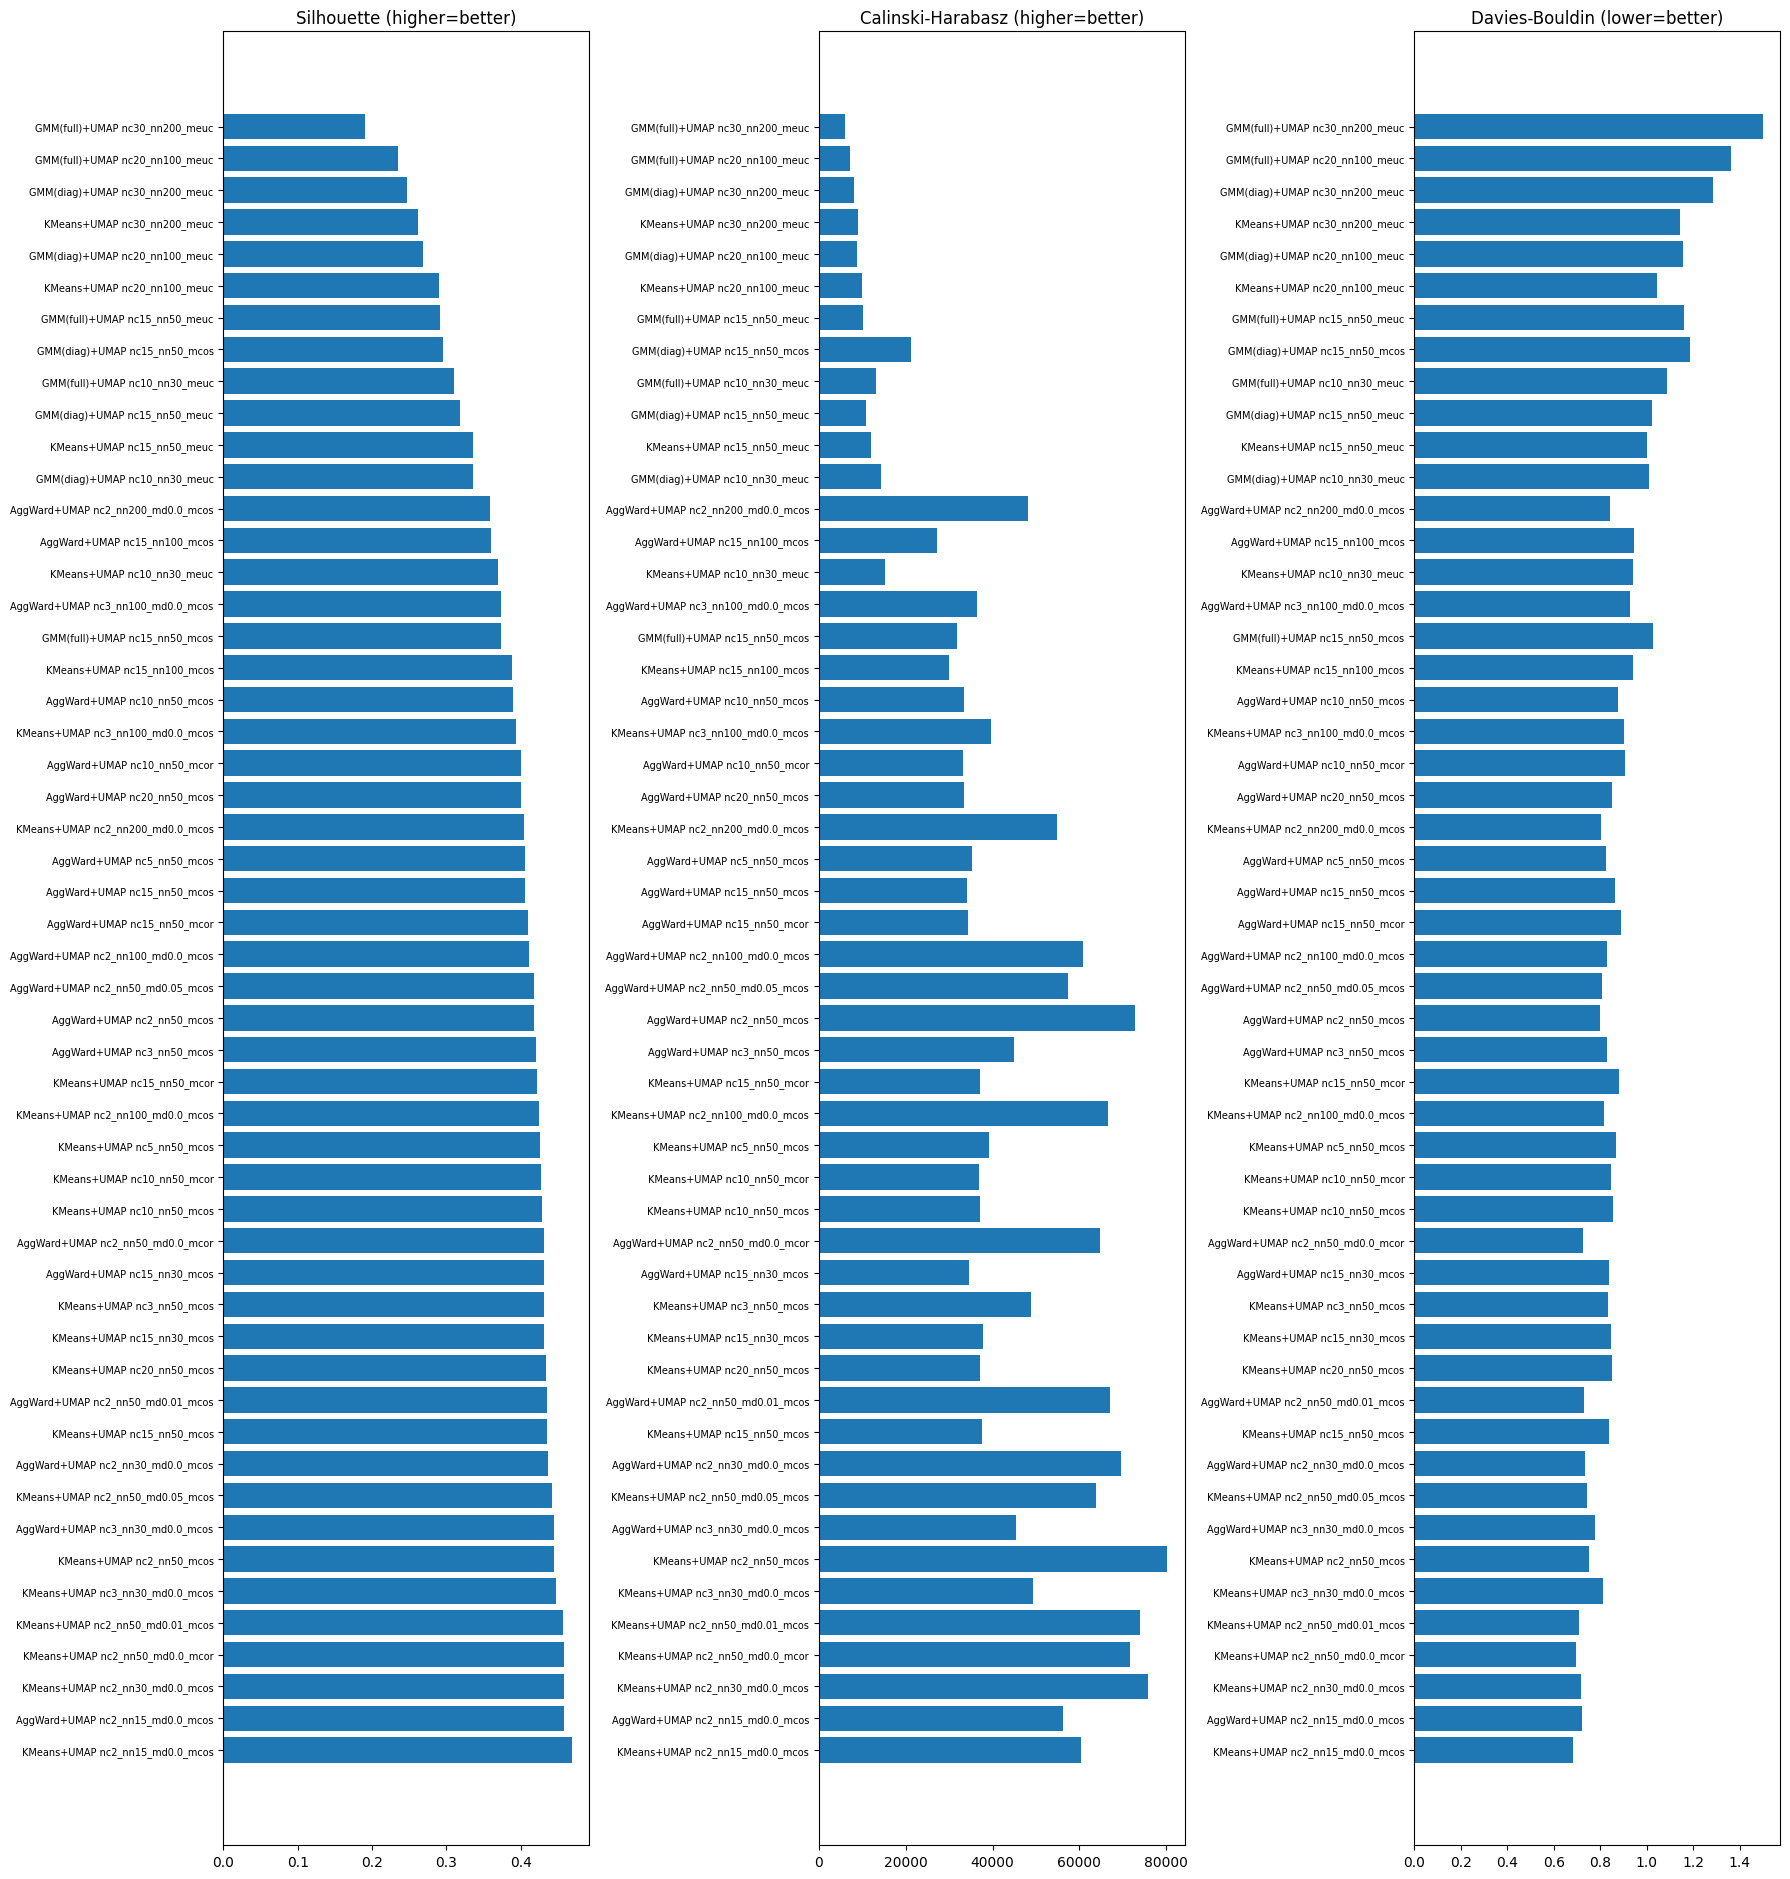

In [ ]:
## Results summary + internal metric plot
df_res = pd.DataFrame([{k: v for k, v in r.items() if k != 'labels'} for r in results])
df_res = df_res.sort_values('silhouette', ascending=False).reset_index(drop=True)
print(df_res[['name', 'silhouette', 'ch', 'db']].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, max(5, len(results) * 0.35)))
names = df_res['name'].tolist()

axes[0].barh(names, df_res['silhouette']); axes[0].set_title('Silhouette (higher=better)')
axes[1].barh(names, df_res['ch']);         axes[1].set_title('Calinski-Harabasz (higher=better)')
axes[2].barh(names, df_res['db']);         axes[2].set_title('Davies-Bouldin (lower=better)')
for ax in axes:
    ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig('internal_metrics.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
## Generate predictions.txt from best model by Silhouette score
best = max(results, key=lambda r: r['silhouette'])
print(f"Best model : {best['name']}")
print(f"Silhouette : {best['silhouette']:.4f}")

# Convert 0-indexed sklearn labels to 1-indexed (1..39) for submission
submission = best['labels'] + 1
assert 1 <= submission.min() and submission.max() <= K
assert len(submission) == len(X)
print(f"Cluster IDs used: {sorted(set(submission.tolist()))}")

np.savetxt('predictions.txt', submission, fmt='%d')
print(f"\nSaved predictions.txt — {len(submission)} lines")

Best model : KMeans+UMAP nc2_nn15_md0.0_mcos
Silhouette : 0.4684
Cluster IDs used: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]

Saved predictions.txt — 34500 lines
